# Convolution by Hand

## Begin with a small image and a calculation you can see

An image becomes a grid of measurements before a neural network can process it. A convolutional layer reads small neighborhoods of those measurements and applies the same learned calculation at many locations. This makes it a useful starting point for finding local visual patterns.

Imagine a bright vertical stripe in a tiny grayscale image. We will choose a filter that responds when the right side of a two-by-two patch is bright, calculate all four outputs, then explore what changes with stride, padding, channels, and training.

The chosen filter is a teaching device. It is not a trained object detector or a promise that a large model will learn the same feature. Training adjusts filters according to a task loss and the examples supplied.

The [code companion](33_Convolution_by_Hand.ipynb) copies this filter into a bias-free PyTorch layer, verifies every output, and max-pools the result. [Images as Tensors](20_Images_as_Tensors_and_Why_CNNs_Work_Notes.ipynb) explains the input representation; [CNN Architecture and Training](34_CNN_Architecture_and_Training_Notes.ipynb) builds a larger classifier.


## Inspect the input, filter, and output grid

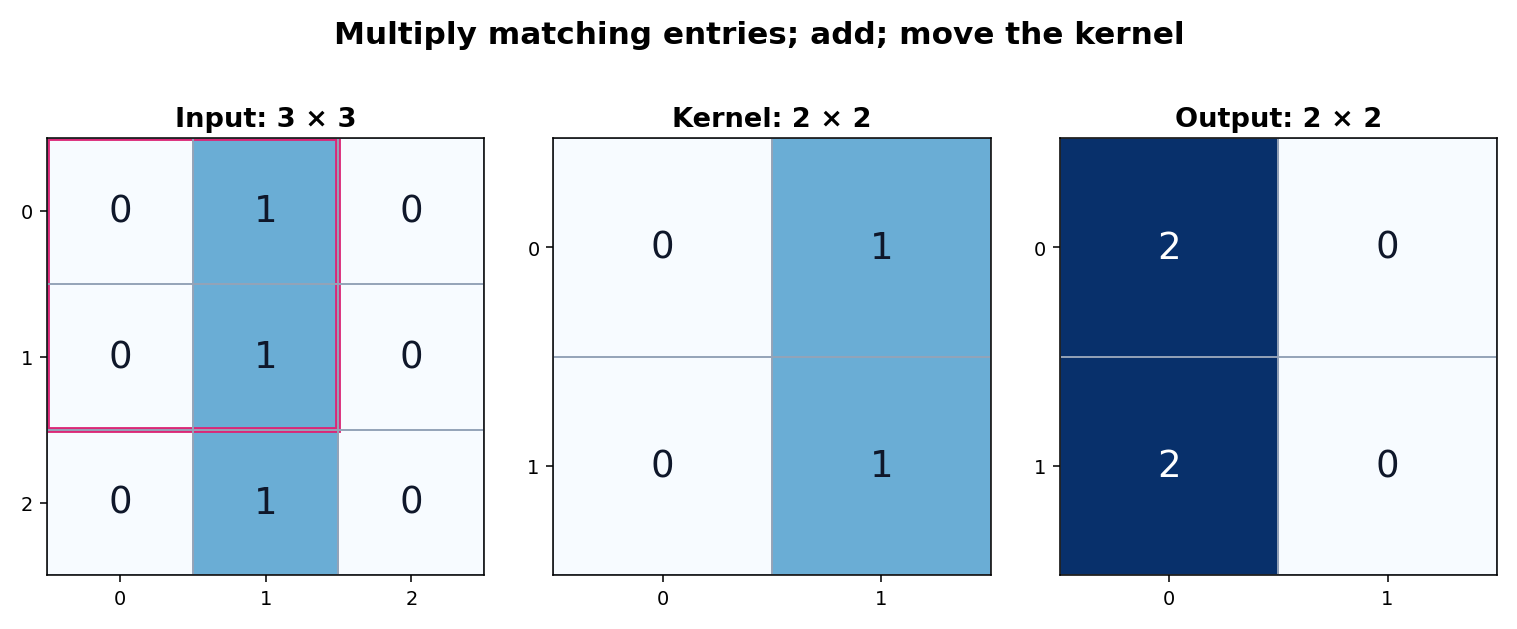

Use:

$$X=\begin{bmatrix}0&1&0\\0&1&0\\0&1&0\end{bmatrix},\qquad K=\begin{bmatrix}0&1\\0&1\end{bmatrix}.$$

The input has height three and width three. The kernel has height two and width two. With stride one and no padding, its top-left corner can start at rows zero or one and columns zero or one.

That gives four patches and therefore a two-by-two output. We will write the upper-left output as $Y_{0,0}$ and track which input coordinates contributed to it.

The output is a **feature map**: a grid of responses to a shared local calculation. Its positions correspond to receptive regions of the input, not directly to class labels.


## Calculate the first two patches entry by entry

At output position $(0,0)$, the patch is $[[0,1],[0,1]]$. Multiply matching entries by $K$:

| Patch coordinate | Input value | Kernel value | Product |
| --- | --- | --- | --- |
| Top left | 0 | 0 | 0 |
| Top right | 1 | 1 | 1 |
| Bottom left | 0 | 0 | 0 |
| Bottom right | 1 | 1 | 1 |

The sum is two. Move the kernel's start one column to the right. The new patch is $[[1,0],[1,0]]$:

$$Y_{0,1}=1(0)+0(1)+1(0)+0(1)=0.$$

The first patch puts bright pixels under the kernel's nonzero entries; the second does not. This is why the selected filter gives different responses at neighboring positions, even though both patches include part of the same stripe.

No activation, pooling, or bias has been applied yet. These values are the raw bias-free local sums.


## Finish all four outputs and explain weight sharing

The lower row of patch starts repeats the same two patch patterns because all three input rows are identical.

| Output coordinate | Patch | Products summed | Output |
| --- | --- | --- | --- |
| $(0,0)$ | $[[0,1],[0,1]]$ | $0+1+0+1$ | 2 |
| $(0,1)$ | $[[1,0],[1,0]]$ | $0+0+0+0$ | 0 |
| $(1,0)$ | $[[0,1],[0,1]]$ | $0+1+0+1$ | 2 |
| $(1,1)$ | $[[1,0],[1,0]]$ | $0+0+0+0$ | 0 |

Thus:

$$Y=\begin{bmatrix}2&0\\2&0\end{bmatrix}.$$

Every output uses the same four kernel entries. We do not learn four different filters for these four locations. **Weight sharing** means one parameter can affect many output positions and can receive learning signals from all those uses.

An optional scalar bias for this output channel would be added at every position. With bias -0.5, the raw map becomes $[[1.5,-0.5],[1.5,-0.5]]$. The companion omits bias so its four parameters are exactly the four kernel entries.


## Distinguish deep-learning convolution from a flipped mathematical kernel

Deep-learning convolution layers generally compute cross-correlation: the kernel is used in its stored orientation. A mathematical convolution flips the kernel along the spatial axes before the local products.

For the chosen kernel, a spatial flip gives $[[1,0],[1,0]]$. Applying that flipped kernel to this input produces $[[0,2],[0,2]]$, rather than the companion's $[[2,0],[2,0]]$.

| Operation in this example | Kernel orientation | Output |
| --- | --- | --- |
| Stored-orientation cross-correlation | $[[0,1],[0,1]]$ | $[[2,0],[2,0]]$ |
| Spatially flipped calculation | $[[1,0],[1,0]]$ | $[[0,2],[0,2]]$ |

Many libraries call the first operation convolution. The distinction matters when matching a hand calculation or a signal-processing formula to code. If filters are learned freely, their stored coefficients can learn the needed orientation, but the numerical verification still requires a consistent definition.

For the companion's implementation contract, see the [PyTorch Conv2d documentation](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html).


## Predict output size before allocating a layer

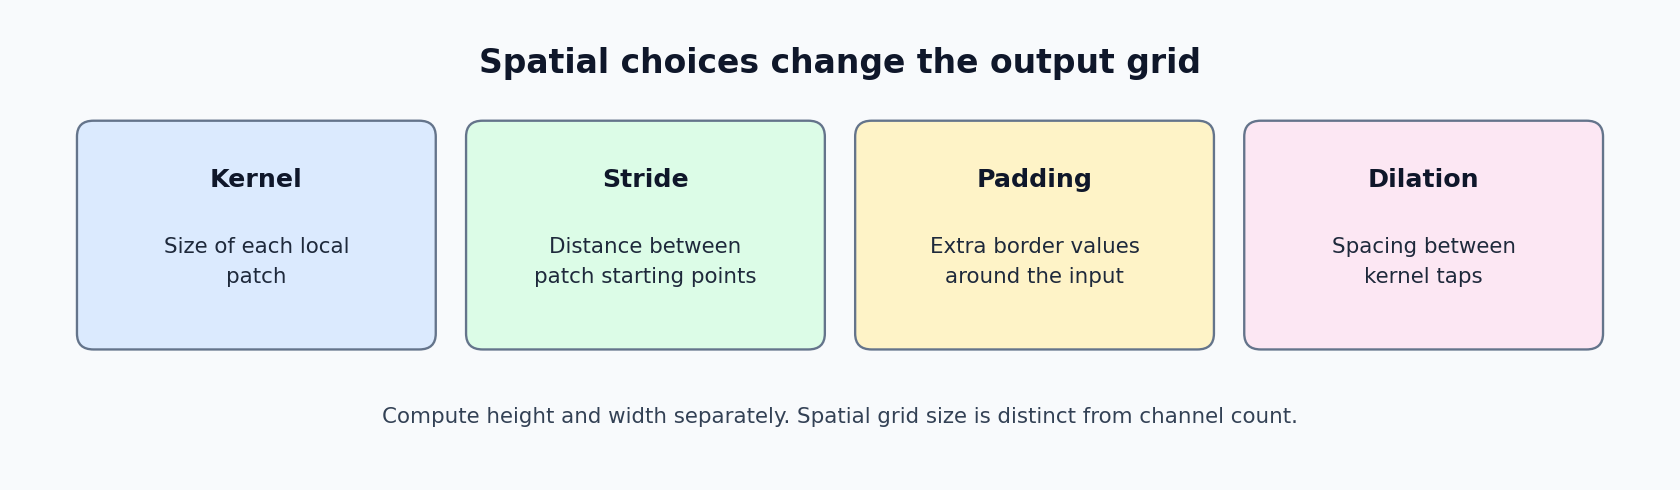

For one spatial dimension, symmetric padding $P$, stride $S$, kernel size $K$, and dilation $d$ give effective kernel extent $K_{eff}=d(K-1)+1$. The output extent is:

$$N_{out}=\left\lfloor\frac{N+2P-K_{eff}}{S}\right\rfloor+1.$$

| Input $N$ | Kernel $K$ | Padding $P$ | Stride $S$ | Dilation $d$ | Output |
| --- | --- | --- | --- | --- | --- |
| 3 | 2 | 0 | 1 | 1 | 2 |
| 3 | 2 | 0 | 2 | 1 | 1 |
| 5 | 3 | 1 | 2 | 1 | 3 |
| 6 | 3 | 0 | 2 | 1 | 2 |
| 7 | 3 | 0 | 1 | 2 | 3 |

Compute height and width separately for rectangular inputs or kernels. The floor discards a starting position if the whole effective kernel would not fit. If the padded input is smaller than the effective kernel, a normal valid output is unavailable and the configuration must be changed.


## Change stride and padding without changing the kernel's meaning

Stride is the spacing between adjacent patch starts. On the original three-by-three input, stride two with the two-by-two kernel gives only one valid start at $(0,0)$, so the output is $[[2]]$.

Padding adds border values around the input. With one zero on each side and stride one, the same input/kernel configuration has output extent four. Some border patches now include synthetic zeros rather than only measured pixels.

| Choice | Effect | What it does not do |
| --- | --- | --- |
| Larger stride | Fewer sampled patch starts | Does not enlarge the filter parameter grid |
| Zero padding | Allows more border starts | Does not add observed image content |
| Larger kernel | Reads a broader local region | Does not necessarily preserve spatial size |
| Dilation | Spaces kernel taps farther apart | Does not add weights between those taps |

Padding affects boundary responses and should be part of the model's input contract. Reflecting or replicating boundary values is different from zero padding. “Same spatial size” describes an output-size goal under a supported configuration, not a universal property of every convolution.


## Add channels by summing local evidence

For multiple input channels, one output channel sums contributions from every input channel and spatial kernel location:

$$Y_{o,r,c}=b_o+\sum_i\sum_u\sum_vK_{o,i,u,v}X_{i,r+u,c+v}$$

for the stride-one, undilated, unpadded example. The full rule adjusts the input coordinates for stride, dilation, and padding.

Consider two one-by-one input channels with values two and three. An output filter with channel weights one and -1 and bias 0.5 gives $2(1)+3(-1)+0.5=-0.5$. Another output filter can use different weights to produce a different feature at the same location.

| Quantity | Meaning |
| --- | --- |
| Input channels | Measurements supplied at each input position |
| Output channels | Different learned local responses |
| Kernel tensor | One input-channel/spatial weighting for each output channel |

A standard convolution mixes channels while filtering spatially. A one-by-one convolution still performs learned channel mixing even though it has no neighborhood beyond the current spatial position.


## Count parameters independently of output grid size

For a standard, ungrouped convolution with $C_{in}$ input channels, $C_{out}$ output channels, and kernel $K_h\times K_w$:

$$N_{weights}=C_{out}C_{in}K_hK_w,$$
$$N_{parameters}=N_{weights}+C_{out}\quad\text{if biases are present}.$$

| Layer | Weights | Biases | Total |
| --- | --- | --- | --- |
| Companion: $1\to1$, $2\times2$, no bias | 4 | 0 | 4 |
| $2\to3$, $3\times3$, bias | 54 | 3 | 57 |
| $3\to8$, $1\times1$, bias | 24 | 8 | 32 |

The number of output positions changes how often weights are used, not how many distinct weights exist. Applying the companion's filter to a larger image still uses four learned coefficients.

Bias is per output channel, not per output pixel. Grouped and depthwise convolutions use a restricted channel-connectivity pattern, changing the count. [Important CNN Designs](35_Important_CNN_Designs_Notes.ipynb) calculates that restriction in detail.


## Apply an activation and a pooling rule as separate stages

ReLU computes $\max(0,z)$ coordinatewise. It leaves the original feature map unchanged because its entries are nonnegative. On $[[2,-1],[0,3]]$, it would return $[[2,0],[0,3]]$.

The companion then applies a two-by-two max pool to $[[2,0],[2,0]]$, returning the single value two. A two-by-two average pool over the same map would return one.

| Stage | Learned coefficients? | Operation |
| --- | --- | --- |
| Convolution | Yes | Shared local weighted sums |
| ReLU | No | Replace negative values with zero |
| Max pooling | No | Retain a local maximum |
| Average pooling | No | Retain a local mean |

Pooling reduces resolution and loses information about where responses occurred. The max-pooled value two cannot reconstruct which two input feature positions contained that response.

Max-pool gradients route through selected maxima. This map has a tie between two maxima, so a backward demonstration would need a defined tie behavior. The companion checks only the pooled forward value and makes no claim about which tied position receives a gradient.


## Follow a loss into the shared kernel

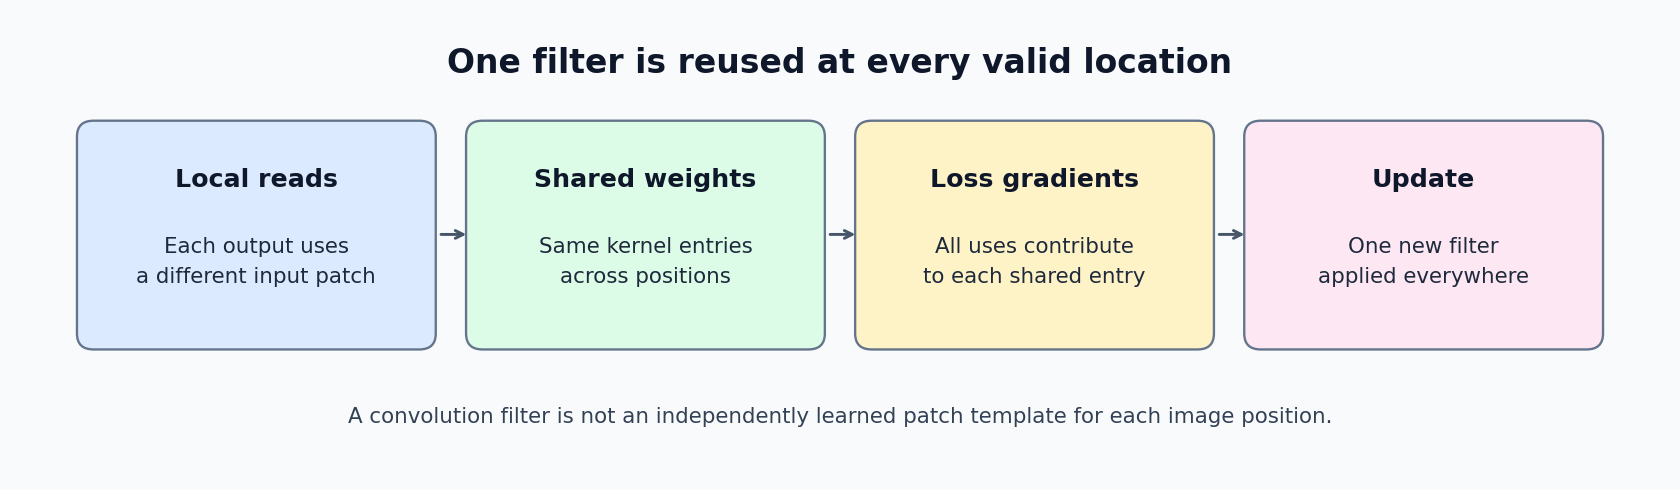

To expose training, use the raw output $Y=[[2,0],[2,0]]$ and a teaching target map of ones. Define:

$$L=\frac12\sum_{r,c}(Y_{r,c}-1)^2=2.$$

The derivative into each raw output is its residual, giving $G=[[1,-1],[1,-1]]$. A kernel entry's derivative sums that output gradient multiplied by the corresponding input pixel over every patch.

| Kernel entry | Contributions from the four patch starts | Total gradient |
| --- | --- | --- |
| Top left | $1(0)-1(1)+1(0)-1(1)$ | -2 |
| Top right | $1(1)-1(0)+1(1)-1(0)$ | 2 |
| Bottom left | $1(0)-1(1)+1(0)-1(1)$ | -2 |
| Bottom right | $1(1)-1(0)+1(1)-1(0)$ | 2 |

Thus $\partial L/\partial K=[[-2,2],[-2,2]]$. Different positions ask the same shared entries to change. These contributions add; there is no separate parameter update for each patch location.


## Apply one update and repeat the actual forward calculation

At learning rate 0.1, SGD changes the chosen kernel to:

$$K_{new}=K-0.1\frac{\partial L}{\partial K}=\begin{bmatrix}0.2&0.8\\0.2&0.8\end{bmatrix}.$$

The stripe-aligned patch now gives $0.8+0.8=1.6$, while the other patch gives $0.2+0.2=0.4$. The new feature map is $[[1.6,0.4],[1.6,0.4]]$.

Its loss is $\tfrac12(0.6^2+(-0.6)^2+0.6^2+(-0.6)^2)=0.72$, lower than two. The update reduced the large responses and raised the zero responses toward the selected map target.

This raw-map regression exercise is not the companion's objective or an image-classification task. It demonstrates how weight sharing and gradients interact. In classification, gradients arrive from a later head and its class loss rather than from a manually specified feature-map target.

Changing the loss reduction from a half-sum to a mean changes the gradient scale. Always differentiate the stated objective, not a remembered derivative from a differently normalized example.


## Understand overlapping input gradients and receptive fields

A shared kernel is reused across positions, and neighboring patches overlap. Therefore one input pixel can influence several outputs and receive the sum of their backward contributions.

For the raw-loss example above with the original kernel, the input gradient is:

$$\frac{\partial L}{\partial X}=\begin{bmatrix}0&1&-1\\0&2&-2\\0&1&-1\end{bmatrix}.$$

The middle row's right-side pixels participate in two vertical patch starts, which explains their doubled contributions. This is the input-side counterpart of accumulating contributions to shared kernel entries.

Stacking local layers also grows the **receptive field**, the input region that can affect a feature. Two stride-one three-by-three convolutions without intermediate downsampling have a five-by-five receptive field for interior outputs.

The two layers are not generally equivalent to one five-by-five convolution: intermediate channels and nonlinear activations change the function. Receptive-field size describes possible dependence, not how much every included pixel actually matters to a trained prediction.


## Interpret the companion and diagnose the arithmetic

The companion allocates input shape $(1,1,3,3)$: batch, channel, height, width. It copies the selected kernel into weight shape $(1,1,2,2)$, performs a forward pass, checks output shape $(1,1,2,2)$, and verifies max pooling and parameter count.

| Mismatch | First check |
| --- | --- |
| Response appears on the opposite side | Kernel flipping convention |
| Output grid is too small or large | Kernel, padding, stride, dilation |
| Multiple channels disagree | Sum over input channels and bias placement |
| Hand gradient differs by a constant | Loss reduction and factor of one half |
| Parameter count grows with image size | Distinguish shared weights from activations |

There is no training loop or held-out image task in this companion. Its assertions verify the chosen arithmetic. The learning update in these notes is a separate fully specified calculation that can be checked independently.


## Practice local reads and keep the roles separate

1. What output extent does a length-seven axis give with kernel three, stride two, no padding, and dilation one?
2. How many parameters are in a bias-enabled standard $2\to4$ convolution with a three-by-three kernel?
3. What is the max-pool result on $[[1,4],[2,3]]$? What is the average?
4. Why do kernel gradients add across output positions?

**Answers.** The output extent is $\lfloor(7-3)/2\rfloor+1=3$. The parameter count is $4(2)(3)(3)+4=76$. Max pooling gives four and average pooling gives 2.5. The same kernel parameters participate in every local read, so the chain rule sums contributions from their repeated uses.

**Remember:** choose a patch, multiply corresponding entries, add channel contributions and bias, write one output, and reuse the same filter at the next allowed start. Activations, pooling, and the task head are additional stages with separate roles.

Continue with [CNN Architecture and Training](34_CNN_Architecture_and_Training_Notes.ipynb) to follow these local operations through a complete classifier.
